# Pedidos e corredores como matrizes

Visualização em matriz das quantidades por item para os pedidos do backlog e para os corredores do armazém.

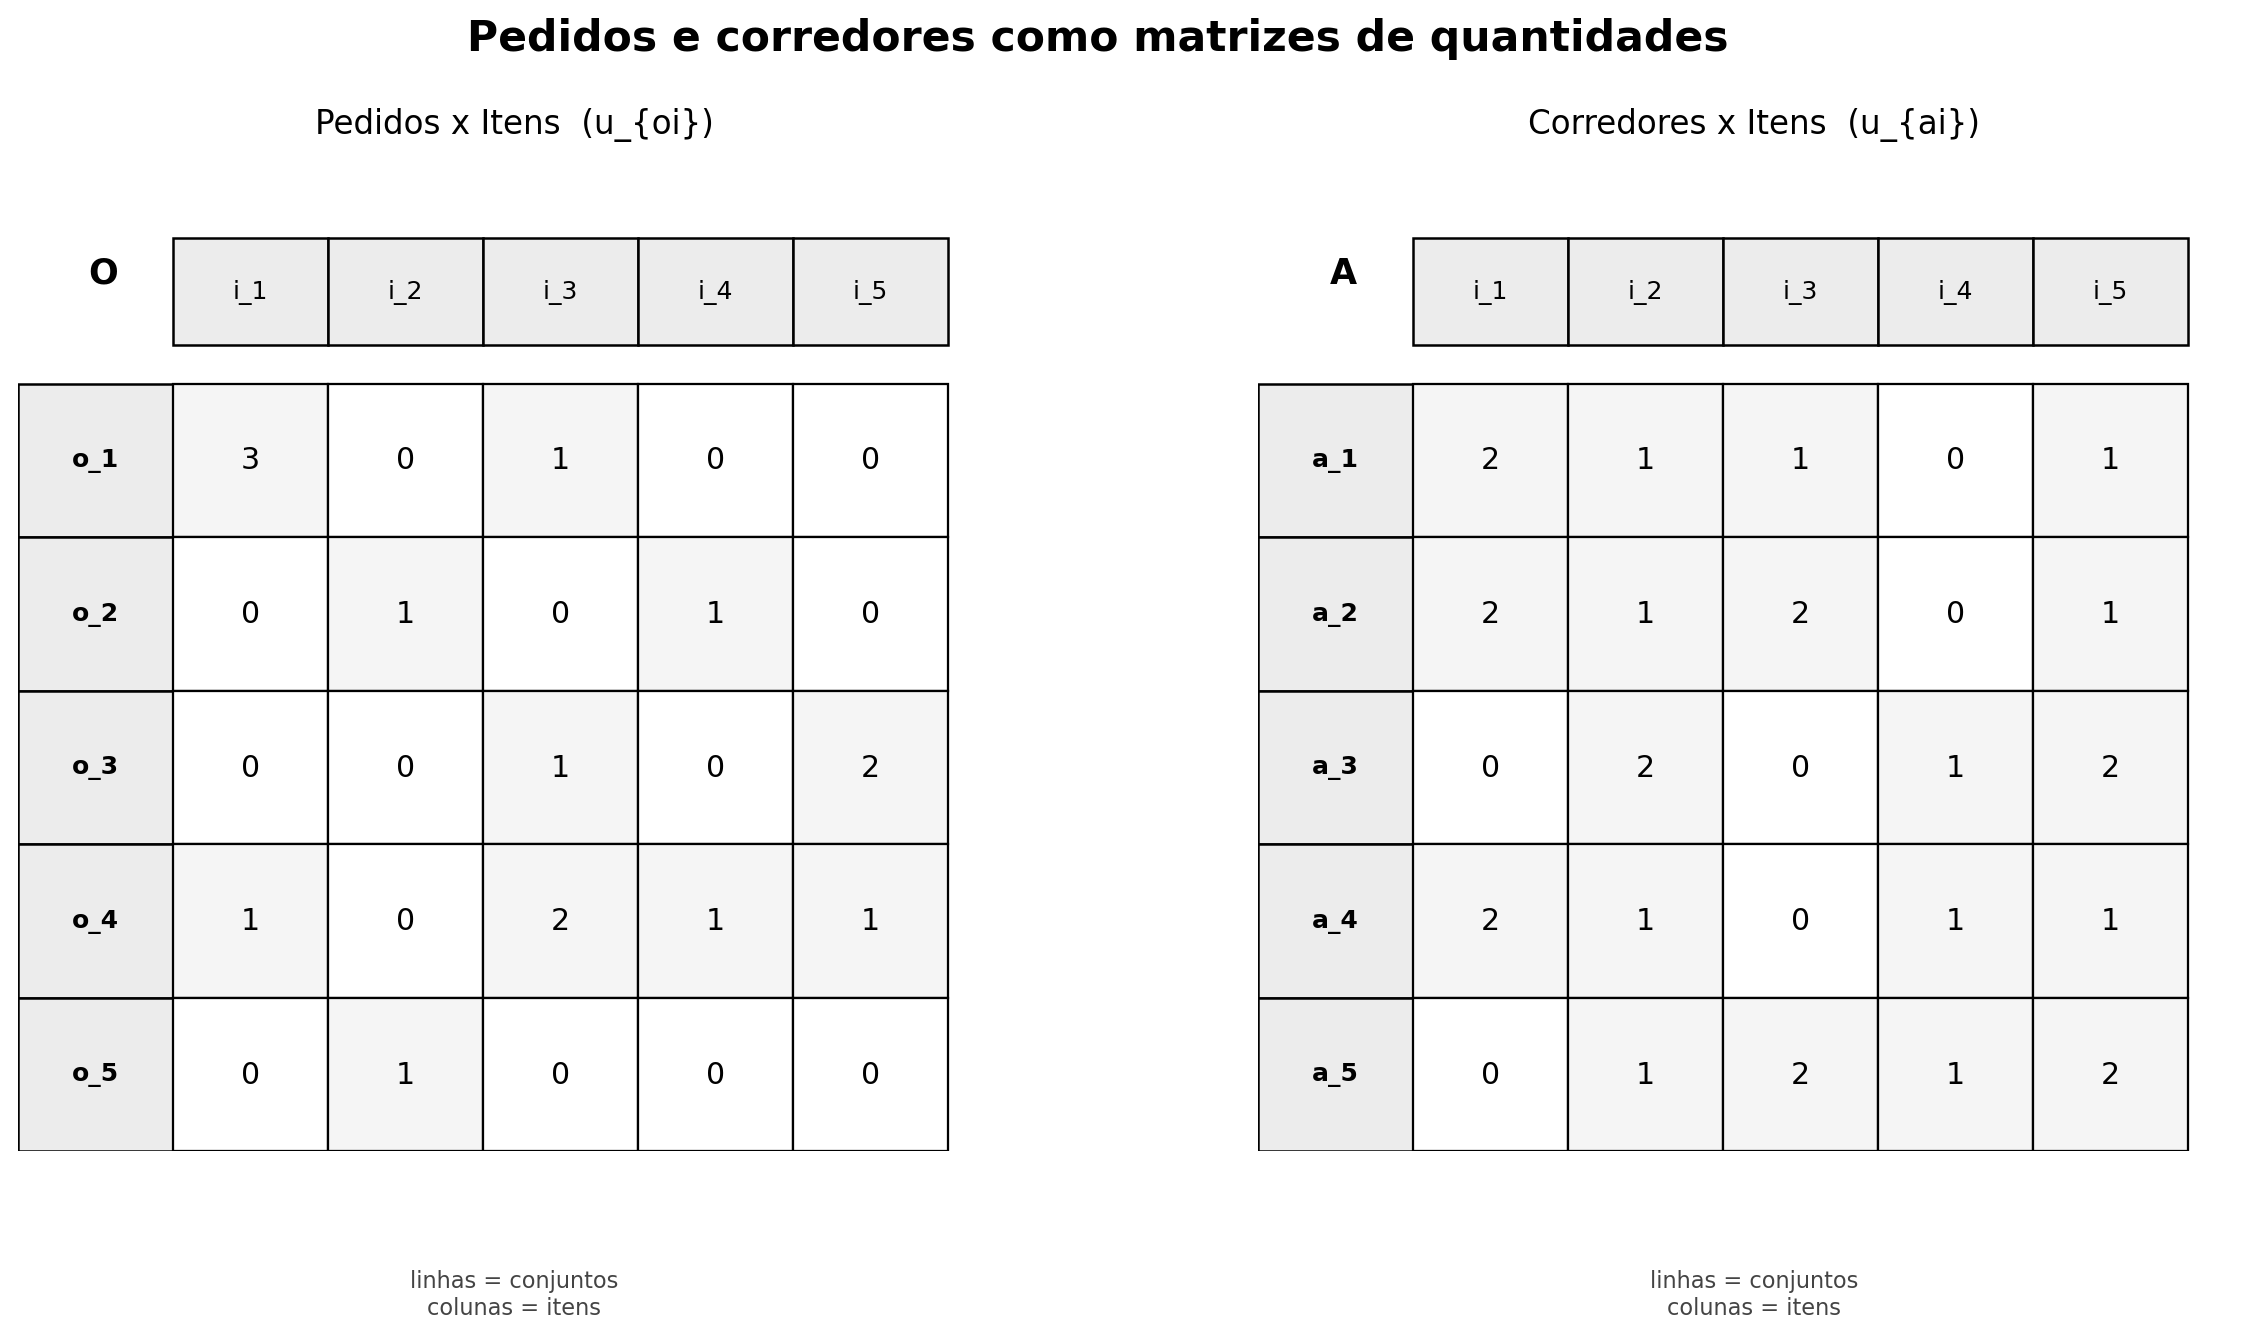

Figura salva em notebooks/outputs/matrizes_pedidos_corredores.png


In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams.update(
    {
        "figure.dpi": 180,
        "font.size": 10,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
    }
)

orders = ["o_1", "o_2", "o_3", "o_4", "o_5"]
items = ["i_1", "i_2", "i_3", "i_4", "i_5"]
aisles = ["a_1", "a_2", "a_3", "a_4", "a_5"]

order_matrix = [
    [3, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 2],
    [1, 0, 2, 1, 1],
    [0, 1, 0, 0, 0],
]

aisle_matrix = [
    [2, 1, 1, 0, 1],
    [2, 1, 2, 0, 1],
    [0, 2, 0, 1, 2],
    [2, 1, 0, 1, 1],
    [0, 1, 2, 1, 2],
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.subplots_adjust(wspace=0.25, top=0.86, bottom=0.08)
fig.suptitle("Pedidos e corredores como matrizes de quantidades", fontsize=17, fontweight="bold")

panels = [
    (axes[0], order_matrix, orders, "Pedidos x Itens  (u_{oi})", "O"),
    (axes[1], aisle_matrix, aisles, "Corredores x Itens  (u_{ai})", "A"),
]

for ax, matrix, row_labels, title, row_group in panels:
    ax.set_xlim(0, len(items) + 1.4)
    ax.set_ylim(0, len(row_labels) + 1.4)
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=14)

    # Column header band.
    ax.text(0.55, len(row_labels) + 0.72, row_group, fontsize=14, fontweight="bold", ha="center", va="center")
    for col, item in enumerate(items, start=1):
        ax.add_patch(
            Rectangle(
                (col, len(row_labels) + 0.25),
                1,
                0.7,
                facecolor="#ececec",
                edgecolor="black",
                linewidth=1.0,
            )
        )
        ax.text(col + 0.5, len(row_labels) + 0.6, item, ha="center", va="center", fontsize=10)

    # Grid body.
    for r, row_label in enumerate(row_labels):
        y = len(row_labels) - r - 1
        ax.add_patch(
            Rectangle(
                (0, y),
                1,
                1,
                facecolor="#ececec",
                edgecolor="black",
                linewidth=1.0,
            )
        )
        ax.text(0.5, y + 0.5, row_label, ha="center", va="center", fontsize=10, fontweight="bold")

        for c, value in enumerate(matrix[r], start=1):
            fill = "#ffffff" if value == 0 else "#f5f5f5"
            ax.add_patch(
                Rectangle(
                    (c, y),
                    1,
                    1,
                    facecolor=fill,
                    edgecolor="black",
                    linewidth=0.9,
                )
            )
            ax.text(c + 0.5, y + 0.5, str(value), ha="center", va="center", fontsize=12)

    ax.text(0.5, -0.12, "linhas = conjuntos\ncolunas = itens", transform=ax.transAxes, ha="center", va="top", fontsize=9, color="#444444")

out_dir = Path("notebooks/outputs")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "matrizes_pedidos_corredores.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
plt.show()
print(f"Figura salva em {out_path}")